In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
import gc
from mnp.ingestion.loader import load_endes
from IPython.display import display

from mnp.utils.profiler import centrar_notebook
centrar_notebook()

# Carga de historial desde 2007 para RECH0
history = load_endes(
        year=range(2007, 2025),
        module="household",
        record="household_characteristics",
        meta=True
    )

frames = []
latest_year_labels = {}
col_labels_hist = {}
value_labels_history = {}

for year in sorted(list(history.keys())):
    year_df, year_meta = history.pop(year)
    frames.append(year_df.assign(year=year))
    latest_year_labels.update(year_meta.column_names_to_labels)
    col_labels_hist[year] = year_meta.column_names_to_labels
    value_labels_history[year] = year_meta.variable_value_labels

df_rech0 = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

all_cols = set()
for cols in col_labels_hist.values():
    all_cols.update(cols)

print(f"Registros RECH0 totales: {len(df_rech0)}")
print(f"Columnas RECH0 totales: {df_rech0.shape[1]}")
df_rech0.head(3)

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k
2026-06-03 05:49:01.995 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /workspace


2026-06-03 05:49:02.206 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-06-03 05:49:02.604 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-06-03 05:49:03.059 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-06-03 05:49:03.368 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-06-03 05:49:03.820 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-06-03 05:49:04.485 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-06-03 05:49:04.911 | INFO     | mnp.ingestion.loader:load_e

,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,year,HV005A,ID1,longitudx,latitudy,HV002A,hv005,HV005X,hv022,codccpp,nomccpp,long_ccpp,lat_ccpp,ubigeo,nconglome,CODCCPP,NOMCCPP,UBIGEO,NCONGLOME,LONGITUDX,LATITUDY,NCONGLOME1
0,1 4,PE5,1.0,4.0,1.0,1.0,313643.0,3.0,2005.0,1263.0,3.0,1.0,0.0,3.0,3.0,0.0,1.0,30.0,2.0,7.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,0.0,NaN,1.0,NaN,8.0,108696.0,0.0,2335.0,1.0,1.0,0.0,1.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 10,PE5,1.0,10.0,4.0,1.0,313643.0,3.0,2005.0,1263.0,4.0,1.0,0.0,4.0,2.0,1.0,1.0,29.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,0.0,NaN,1.0,NaN,8.0,108696.0,1.0,2335.0,1.0,1.0,0.0,1.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 16,PE5,1.0,16.0,2.0,1.0,313643.0,3.0,2005.0,1263.0,5.0,2.0,0.0,5.0,5.0,0.0,1.0,31.0,3.0,7.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,0.0,NaN,1.0,NaN,8.0,108696.0,0.0,2335.0,2.0,1.0,0.0,1.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.1. Schema Drift (Mutación de Column Labels)

In [2]:
from mnp.utils.profiler import analyze_schema_drift, print_schema_drift_report

all_cols_sch, stable_schema, mutated_schema = analyze_schema_drift(col_labels_hist)
print_schema_drift_report(all_cols_sch, stable_schema, mutated_schema)

REPORTE GLOBAL DE MUTACIÓN DE DESCRIPCIONES DE COLUMNAS (COLUMN LABELS)

Total de columnas detectadas: 61

Descripciones estables: 13
HV005A (Apariciones: 1 años)
  - Años 2008                                  : Sample weight Departamental
ID1 (Apariciones: 13 años)
  - Años 2010-2016, 2019-2024                  : Año
HV005X (Apariciones: 1 años)
  - Años 2015                                  : Factor de ponderación niño menor de 5 años 2015
hv022 (Apariciones: 1 años)
  - Años 2016                                  : Estrato
codccpp (Apariciones: 2 años)
  - Años 2016-2017                             : Codigo de centro poblado
nomccpp (Apariciones: 2 años)
  - Años 2016-2017                             : Nombre de centro poblado
long_ccpp (Apariciones: 1 años)
  - Años 2017                                  : Longitud
lat_ccpp (Apariciones: 1 años)
  - Años 2017                                  : Latitud
ubigeo (Apariciones: 1 años)
  - Años 2018                                  : ubige

## 1.2. Schema Drift (Mutación de Value Labels)

In [3]:
from mnp.utils.profiler import analyze_val_drift, print_val_drift_report

all_val_cols, stable_val_labels, mutated_val_labels = analyze_val_drift(value_labels_history)
print_val_drift_report(all_val_cols, stable_val_labels, mutated_val_labels)

REPORTE GLOBAL DE MUTACIÓN DE ETIQUETAS DE VALORES (2007 - 2024)

Total de columnas con mapeo de valores detectadas: 11

Etiquetas de valores estables: 3
HV023 (Apariciones: 18 años)
  - Años 2007-2024                        : 1.0 (Amazonas) | 2.0 (Ancash) | 3.0 (Apurimac) | 4.0 (Arequipa) | 5.0 (Ayacucho) | 6.0 (Cajamarca) | 7.0 (Callao) | 8.0 (Cusco) | 9.0 (Huancavelica) | 10.0 (Huanuco) | 11.0 (Ica) | 12.0 (Junin) | 13.0 (La Libertad) | 14.0 (Lambayeque) | 15.0 (Lima) | 16.0 (Loreto) | 17.0 (Madre de Dios) | 18.0 (Moquegua) | 19.0 (Pasco) | 20.0 (Piura) | 21.0 (Puno) | 22.0 (San Martin) | 23.0 (Tacna) | 24.0 (Tumbes) | 25.0 (Ucayali)
HV024 (Apariciones: 18 años)
  - Años 2007-2024                        : 1.0 (Amazonas) | 2.0 (Ancash) | 3.0 (Apurimac) | 4.0 (Arequipa) | 5.0 (Ayacucho) | 6.0 (Cajamarca) | 7.0 (Callao) | 8.0 (Cusco) | 9.0 (Huancavelica) | 10.0 (Huanuco) | 11.0 (Ica) | 12.0 (Junin) | 13.0 (La Libertad) | 14.0 (Lambayeque) | 15.0 (Lima) | 16.0 (Loreto) | 17.0 (Madre de 

## 1.5. Matriz Histórica de Variables (Evolución del Schema)

In [4]:
# Filas = Años, Columnas = Variables
df_history_matrix = pd.DataFrame(col_labels_hist).T.sort_index()

# Reemplazamos los valores por el nombre de la propia variable (si existe) o vacío si no existía ese año
for col in df_history_matrix.columns:
    df_history_matrix[col] = df_history_matrix[col].where(df_history_matrix[col].isna(), col)

df_history_matrix = df_history_matrix.fillna("")

display(df_history_matrix)

,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,HV005A,ID1,longitudx,latitudy,HV002A,hv005,HV005X,hv022,codccpp,nomccpp,long_ccpp,lat_ccpp,ubigeo,nconglome,CODCCPP,NOMCCPP,UBIGEO,NCONGLOME,LONGITUDX,LATITUDY,NCONGLOME1
2007,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,,,,,,,,,,,,,,,,,,,,
2008,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,HV005A,,,,,,,,,,,,,,,,,,,,
2009,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,,,,,,,,,,,,,,,,,,,,
2010,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,,,,,,,,,,,,,,,,,
2011,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,,,,,,,,,,,,,,,,,
2012,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,HV002A,,,,,,,,,,,,,,,,
2013,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,HV002A,,,,,,,,,,,,,,,,
2014,HHID,HV000,HV001,HV002,HV003,HV004,,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,HV002A,,,,,,,,,,,,,,,,
2015,HHID,HV000,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,HV022,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,HV002A,,HV005X,,,,,,,,,,,,,,
2016,HHID,HV000,HV001,HV002,HV003,HV004,,HV006,HV007,HV008,HV009,HV010,HV011,HV012,HV013,HV014,HV015,HV016,HV017,HV018,HV019,HV020,HV021,,HV023,HV024,HV025,HV026,HV027,HV028,HV030,HV031,HV032,HV033,HV035,HV040,HV041,HV042,HV043,HV044,,ID1,longitudx,latitudy,HV002A,hv005,,hv022,codccpp,nomccpp,,,,,,,,,,,


## 2. Master Data Dictionary (Reporte Combinado)

In [5]:
import pandas as pd
from mnp.utils.profiler import (
    analyze_logical_types, metric_latest_label, metric_logical_type, 
    metric_pandas_dtype, metric_has_value_labels, metric_nulls, 
    metric_years_present, metric_total_years
)

# 💡 ENFOQUE HÍBRIDO: IDs locales o conocidos
known_ids = ["HHID", "HV000", "HV001", "HV002", "HV002A", "HV003"]
logical_types_dict = analyze_logical_types(df_rech0, all_cols, value_labels_history, col_labels_hist, forced_ids=known_ids)

# 1. El DataFrame base son las variables originales
df_report = pd.DataFrame(index=sorted(list(all_cols)))
df_report.index.name = "Variable"

# 2. Los "Enchufes" explícitos usando el map() nativo de Pandas
df_report["Latest Column Label"] = df_report.index.map(lambda c: metric_latest_label(c, latest_year_labels))
df_report["Tipo Lógico"]         = df_report.index.map(lambda c: metric_logical_type(c, logical_types_dict))
df_report["Pandas Dtype"]        = df_report.index.map(lambda c: metric_pandas_dtype(c, df_rech0.dtypes))
df_report["Value Labels"]        = df_report.index.map(lambda c: metric_has_value_labels(c, value_labels_history))
df_report["Años Presente"]       = df_report.index.map(lambda c: metric_years_present(c, col_labels_hist))
df_report["Total Años"]          = df_report.index.map(lambda c: metric_total_years(c, col_labels_hist))
df_report["% Nulos"]             = df_report.index.map(lambda c: metric_nulls(c, df_rech0))

df_report.sort_values(by=["Tipo Lógico", "% Nulos"], ascending=[True, False], inplace=True)
display(df_report)

,Latest Column Label,Tipo Lógico,Pandas Dtype,Value Labels,Años Presente,Total Años,% Nulos
Variable,,,,,,,
hv022,Estrato,Categorical,float64,X,2016,1,94.0
HV026,Lugar de residencia,Categorical,float64,X,2007-2024,18,0.6
HV015,Resultado de la entrevista en el hogar,Categorical,float64,X,2007-2024,18,0.0
HV020,Muestra de alguna vez en union,Categorical,float64,X,2007-2024,18,0.0
HV023,Dominio,Categorical,float64,X,2007-2024,18,0.0
HV024,Región,Categorical,float64,X,2007-2024,18,0.0
HV025,Área de residencia,Categorical,float64,X,2007-2024,18,0.0
HV027,Selección para hombre/esposo,Categorical,float64,X,2007-2024,18,0.0
HV042,Selección para medición de hemoglobina,Categorical,float64,X,2007-2024,18,0.0


## 3. Análisis de Nulos por Tipo Lógico
Al agrupar por Tipo Lógico universal (en lugar de categorías de negocio manuales), podemos aplicar reglas de limpieza automáticas más adelante.


ANÁLISIS DE EVOLUCIÓN DE NULOS: CATEGORICAL


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HV015,Resultado de la entrevista en el hogar,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV020,Muestra de alguna vez en union,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV023,Dominio,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV024,Región,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV025,Área de residencia,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV026,Lugar de residencia,0.0,10.170922,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV027,Selección para hombre/esposo,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV042,Selección para medición de hemoglobina,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV043,Hogares seleccionados para el módulo de mujeres de estado,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV044,Selección para el módulo de violencia familiar,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


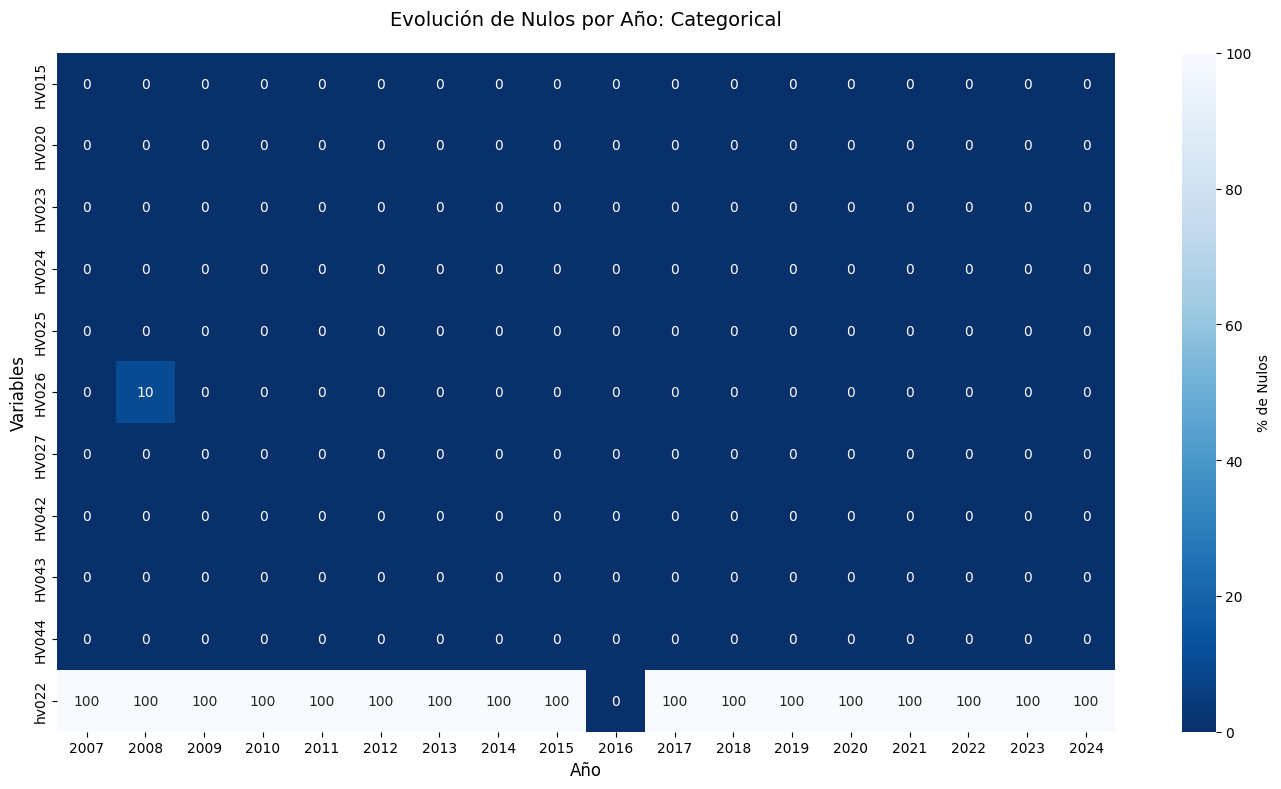

In [9]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech0, 
    cols=logical_types_dict.get("Categorical", []), 
    group_name="Categorical", 
    latest_year_labels=latest_year_labels, 
    cmap="Blues_r", 
    figsize=(14, 8)
)



ANÁLISIS DE EVOLUCIÓN DE NULOS: NUMERICAL


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HV004,Unidad última de muestreo,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV005,Factor de ponderación,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,100.000000,0.000000,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV005A,Sample weight Departamental,100.0,0.0,100.000000,100.0,100.0,100.0,100.000000,100.000000,100.000000,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV005X,Factor de ponderación niño menor de 5 años 2015,100.0,100.0,100.000000,100.0,100.0,100.0,100.000000,100.000000,0.000000,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV006,Month of interview,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV007,Año de entrevista,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
HV008,Fecha de entrevista meses (CMC),0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV009,Total de personas en el hogar,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV010,Número de mujeres elegibles para entrevista individual,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV011,Número de hombres elegibles por hogar,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


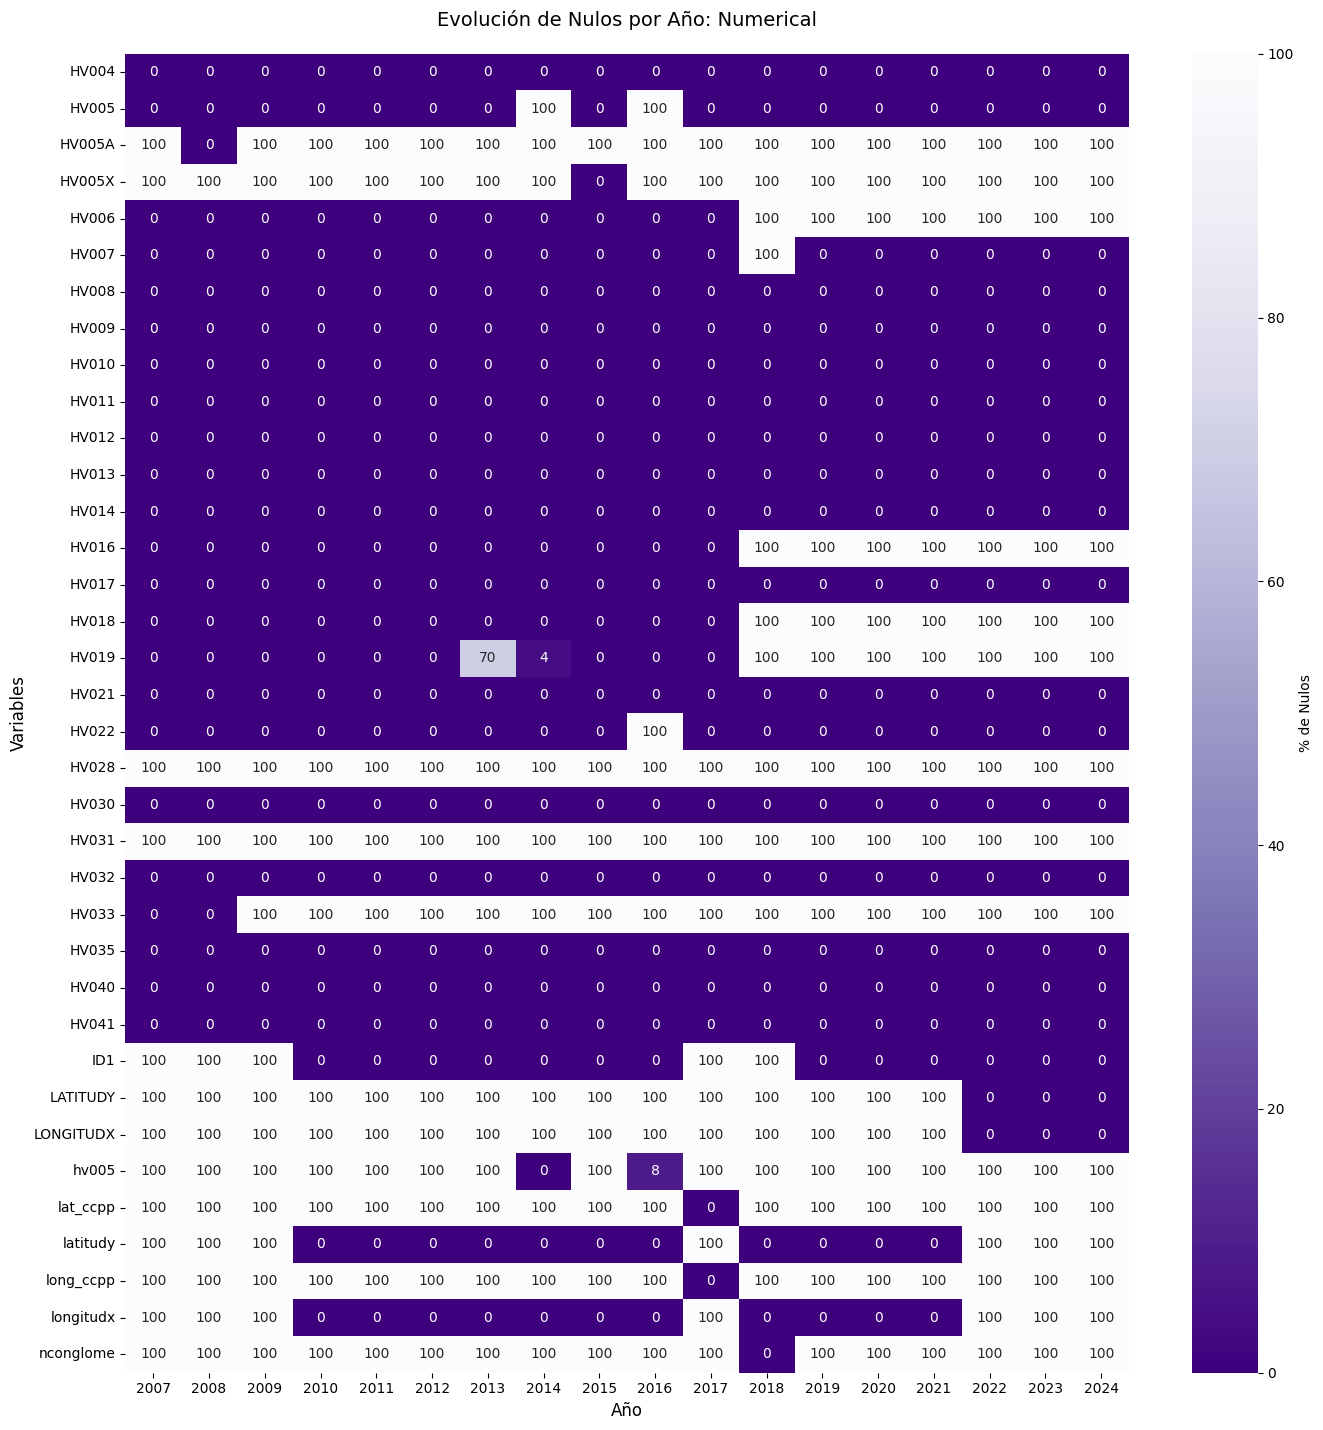

In [10]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech0, 
    cols=logical_types_dict.get("Numerical", []), 
    group_name="Numerical", 
    latest_year_labels=latest_year_labels, 
    cmap="Purples_r", 
    figsize=(14, 8)
)



ANÁLISIS DE EVOLUCIÓN DE NULOS: IDENTIFIER


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
CODCCPP,Codigo de Centro Poblado,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HHID,Identificacion Cuestionario del Hogar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV000,Código del país,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV001,Conglomerado,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV002,Vivienda,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV002A,Hogar,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV003,Número de orden del Informante del cuestionario del hogar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NCONGLOME,Número de Conglomerado (proveniente del marco),100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,100.0
NCONGLOME1,Número de Conglomerado (proveniente del marco),100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0
NOMCCPP,Nombre del Centro Poblado,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


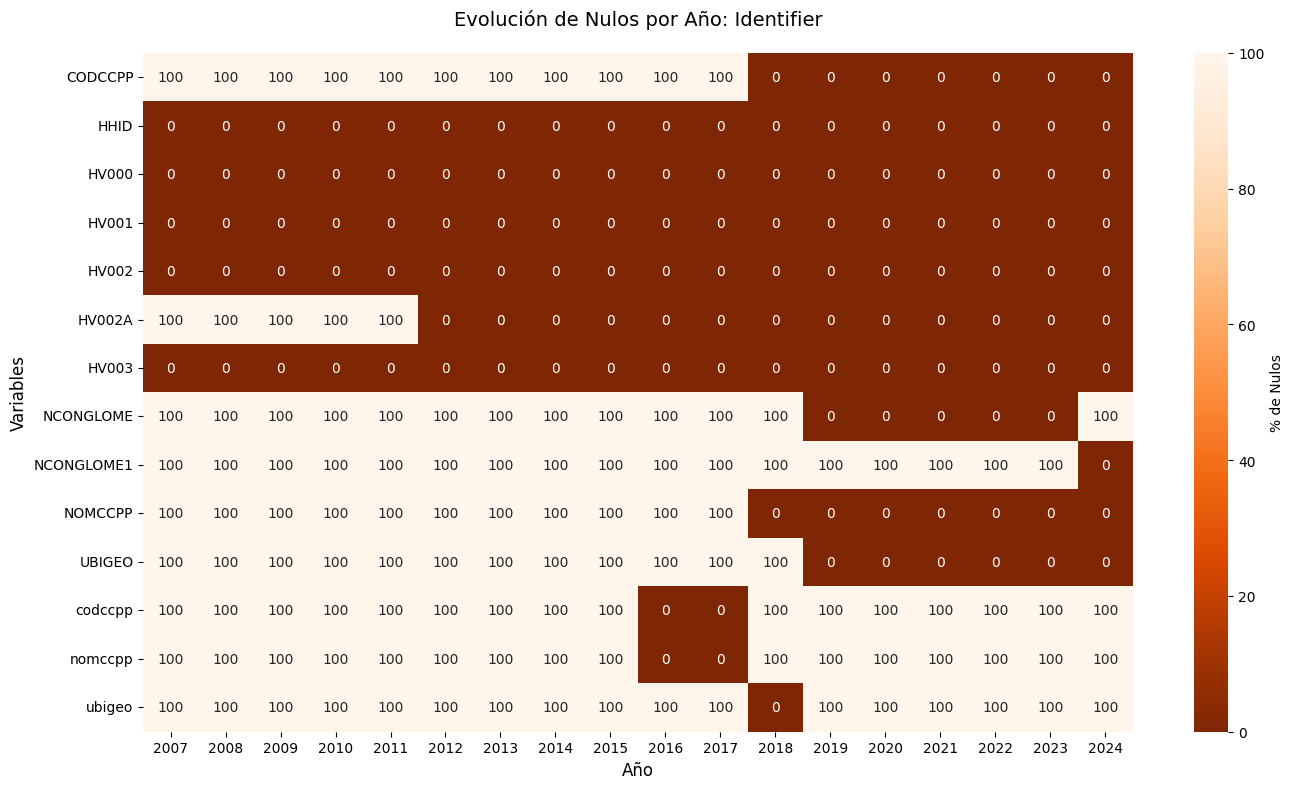

In [8]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech0, 
    cols=logical_types_dict.get("Identifier", []), 
    group_name="Identifier", 
    latest_year_labels=latest_year_labels, 
    cmap="Oranges_r", 
    figsize=(14, 8)
)
